In [2]:
from pathlib import Path

import numpy as np
from src import two_d_loader
from IPython.core.pylabtools import figsize

data_folder = Path("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset")
# data_folder = Path("/Users/persie/PhD_Code/3d_ant_data_rle")

session_list = [6,10,11,13,17,19,20,21,22,23,28,29,30]
obj_ref_frame = [500,180,380,849,459, 59, 842, 24, 93, 176, 2626, 595, 241 ]
prefix = "240905-1616"
skeleton_toml_path = "skeleton.toml"
camera_list = ["strawberry", "coconut", "blueberry", "banana", "avocado"]

In [3]:
#Sessions available for CATAR
catar_session = [11, 19, 21, 29, 30]

In [3]:
from src import two_d_loader

sleap = two_d_loader.load_session("/Users/persie/Desktop/Dataset_for_upload/Data/240905-1616/inputs/tracking", session=11, use_polars=False)


Loaded 5 SLEAP slp files.


In [4]:
from src import two_d_loader
catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=11, use_polars=False)

Loaded 1 CATAR csv files.


## Find matched keypoints between CATAR and SLEAP

Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.


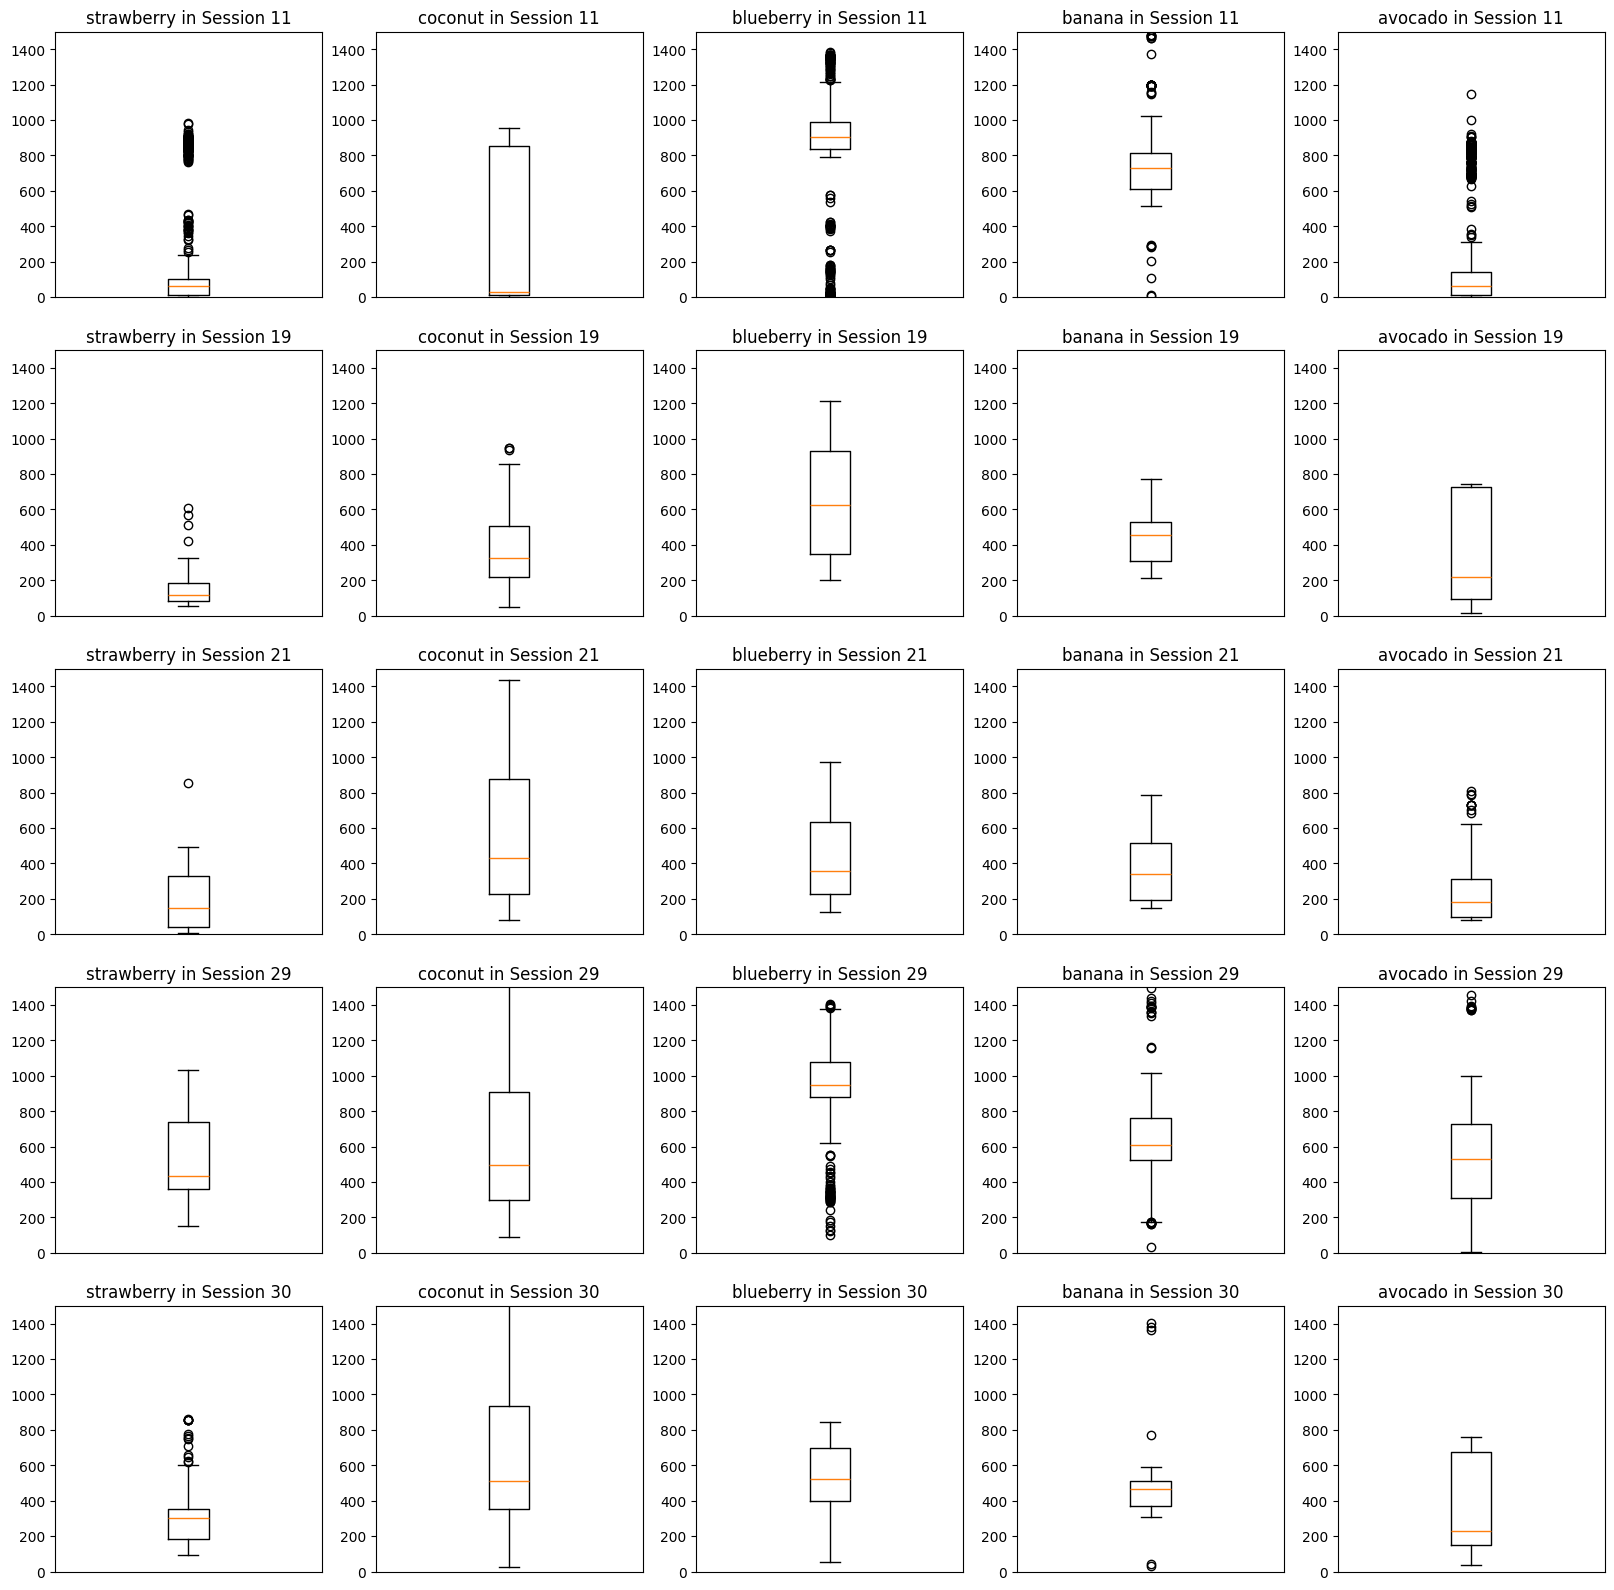

In [37]:
#Find for each keypoint in a CATAR frame
# The closest keypoint in the SLEAP frames
example_keypoints = ["a_L2", "a_R2"]

import pandas as pd
idx = pd.IndexSlice

import matplotlib.pyplot as plt
fig, ax = plt.subplots(len(camera_list), len(catar_session), figsize=(17,17))

for i, session in enumerate(catar_session):

    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=session, use_polars=False)
    for j, camera in enumerate(camera_list):
        error_mag = []
        catar_sub = catar.xs(camera).xs("a_L2", axis=1).loc[0]
        sleap_sub = sleap.xs(camera).xs("a_L2", axis=1)
        all_sleap_frames = np.array(list(sleap_sub.index))[:,1]

        for frame in catar_sub.index:
            #Find the frame in the sleap sub that matches
            if frame in all_sleap_frames:
                matched_points = sleap_sub.loc[idx[:, frame], :].dropna()
                ref_point = catar_sub.loc[frame]
                diff = matched_points - ref_point
                if len(diff) > 0:
                    diff["mag"] = np.sqrt(diff["x"]**2 + diff["y"]**2)
                    closest_error = np.nanmin(diff["mag"])
                    if not np.isnan(closest_error):
                        error_mag.append(closest_error)

        error_array = np.array(error_mag, dtype=np.float64)
        ax[i,j].boxplot(error_array)
        ax[i,j].set_title(f"{camera} in Session {session}")
        ax[i,j].set_ylim(0, 1500)
        ax[i,j].set_xticks([])



in sleap frames with multiple instances of a_l2
array([ 367,  368,  369,  535,  536,  537,  538,  540,  541,  542,  544,
        546,  547,  548,  549,  550,  551,  582,  586,  587,  589,  594,
        604,  605,  611, 2472, 2879, 2938, 2939, 2940, 2941, 2942, 2943,
       2944, 2945, 2946, 2947, 2948, 2949, 2955, 3088, 3090, 3091, 3092,
       3093, 3094, 3095, 3096, 3097, 3098, 3099, 3100, 3101, 3102, 3103,
       3104, 3105, 3106, 3107, 3108, 3109, 3110, 3111, 3112, 3113, 3968,
       4076])

<Axes: xlabel='frame'>

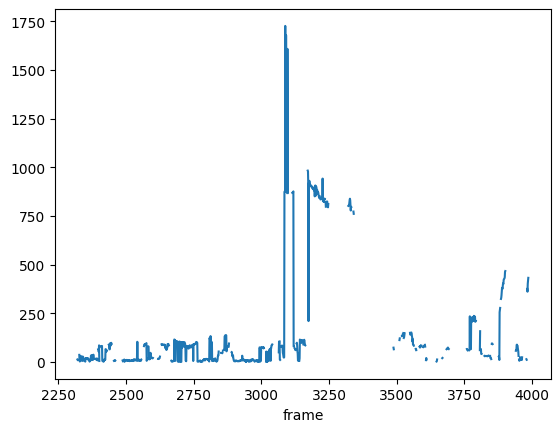

In [5]:
#find out which rows contain the frame from catar in sleap, compare all tracks and pick the closest one

#do it for a single camera for now
camera = "strawberry"

catar_sub = catar.xs(camera).xs("a_L2", axis=1).loc[0]

sleap_sub = sleap.xs(camera).xs("a_L2", axis=1)

# sleap_sub.loc[catar_sub["frame"]]
annotated_index = catar_sub.index #All the catar annotated frames

matched_frames_sleap = sleap_sub.loc(axis=0)[:, annotated_index].droplevel(level=0)

diff = catar_sub - matched_frames_sleap
import numpy as np
diff["mag"] = np.sqrt(diff["x"]**2 + diff["y"]**2)
diff.mag.plot()

## Percentage of Frames Annotated with CATAR in 2D
This is just summed across all views

In [159]:
#How many frames are there across all sessions where the keypoint is present
session_data = {}
for catar_session_name in catar_session:
    session_data[catar_session_name] = {}
    #Load the data
    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=catar_session_name, use_polars=False)

    total_frames = len(catar)
    session_data[catar_session_name]["total_frames"] = total_frames

    print(f"Session {catar_session_name} has {total_frames} frames")

    tracked_left = catar.loc[catar["a_L2", "score"] == 1].index
    session_data[catar_session_name]["tracked_left"] = len(tracked_left)

    print(f"Session {catar_session_name} has {len(tracked_left)} frames where a_L2 is tracked")

    tracked_right = catar.loc[catar["a_R2", "score"] == 1].index
    session_data[catar_session_name]["tracked_right"] = len(tracked_right)

    print(f"Session {catar_session_name} has {len(tracked_right)} frames where a_R2 is tracked")

    # Find instances that repeat in the tracked left and tracked right
    tracked_both = list(set(tracked_left) & set(tracked_right))
    session_data[catar_session_name]["tracked_both"] = len(tracked_both)

    print(f"Session {catar_session_name} has {len(tracked_both)} frames where the a_L2 and a_R2 are tracked")

    #For the tracked both list of tuples, count the number of occurences of each frame

    values, count = np.unique_counts(np.array(tracked_both)[:,2])

    tracked_all_view = np.nonzero(count > 4)
    session_data[catar_session_name]["tracked_all_view"] = len(tracked_all_view[0])
    print(f"Session {catar_session_name} has {len(tracked_all_view[0])} frames where the a_L2 and a_R2 are tracked in all views")


    tracked_two_view = np.nonzero(count > 1)
    session_data[catar_session_name]["tracked_two_view"] = len(tracked_two_view[0])

    print(f"Session {catar_session_name} has {len(tracked_two_view[0])} frames where the a_L2 and a_R2 are tracked in at least 2 views")

    # catar.a_R2.loc[(slice(None), slice(None), [2323])]

    session_data[catar_session_name]["percent_left"] = session_data[catar_session_name]["tracked_left"] / session_data[catar_session_name]["total_frames"] * 100

    session_data[catar_session_name]["percent_right"] = session_data[catar_session_name]["tracked_right"] / session_data[catar_session_name]["total_frames"] * 100

    session_data[catar_session_name]["percent_both"] = session_data[catar_session_name]["tracked_both"] / session_data[catar_session_name]["total_frames"] * 100




Loaded 1 CATAR csv files.
Session 11 has 8395 frames
Session 11 has 4178 frames where a_L2 is tracked
Session 11 has 3439 frames where a_R2 is tracked
Session 11 has 2648 frames where the a_L2 and a_R2 are tracked
Session 11 has 5 frames where the a_L2 and a_R2 are tracked in all views
Session 11 has 927 frames where the a_L2 and a_R2 are tracked in at least 2 views
Loaded 1 CATAR csv files.
Session 19 has 2905 frames
Session 19 has 2005 frames where a_L2 is tracked
Session 19 has 1462 frames where a_R2 is tracked
Session 19 has 1300 frames where the a_L2 and a_R2 are tracked
Session 19 has 9 frames where the a_L2 and a_R2 are tracked in all views
Session 19 has 492 frames where the a_L2 and a_R2 are tracked in at least 2 views
Loaded 1 CATAR csv files.
Session 21 has 3655 frames
Session 21 has 3010 frames where a_L2 is tracked
Session 21 has 2441 frames where a_R2 is tracked
Session 21 has 2378 frames where the a_L2 and a_R2 are tracked
Session 21 has 114 frames where the a_L2 and a_R

In [162]:
#Work out the proportions
total_percents = {}
total_percents["total_frames"] = 0
total_percents["tracked_left"] = 0
total_percents["tracked_right"] = 0
total_percents["tracked_both"] = 0
total_percents["tracked_all_view"] = 0
total_percents["tracked_two_view"] = 0

for catar_session_name in catar_session:
    total_percents["total_frames"] += session_data[catar_session_name]["total_frames"]
    total_percents["tracked_left"] += session_data[catar_session_name]["tracked_left"]
    total_percents["tracked_right"] += session_data[catar_session_name]["tracked_right"]
    total_percents["tracked_both"] += session_data[catar_session_name]["tracked_both"]
    total_percents["tracked_all_view"] += session_data[catar_session_name]["tracked_all_view"]
    total_percents["tracked_two_view"] += session_data[catar_session_name]["tracked_two_view"]


percent_left = total_percents["tracked_left"] / total_percents["total_frames"] * 100

percent_right = total_percents["tracked_right"] / total_percents["total_frames"] * 100

percent_both = total_percents["tracked_both"] / total_percents["total_frames"] * 100

percent_all_view = total_percents["tracked_all_view"] / total_percents["total_frames"] * 100

percent_two_view = total_percents["tracked_two_view"] / total_percents["total_frames"] * 100

print(f"Total frames: {total_percents['total_frames']}")
print(f"Total frames where left is tracked: {total_percents['tracked_left']}")
print(f"Total frames where right is tracked: {total_percents['tracked_right']}")
print(f"Total frames where both are tracked: {total_percents['tracked_both']}")
print(f"Total frames where both are tracked in all views: {total_percents['tracked_all_view']}")
print(f"Total frames where both are tracked in at least 2 views: {total_percents['tracked_two_view']}")

print(f"Percent left : {percent_left}")
print(f"Percent right : {percent_right}")
print(f"Percent both : {percent_both}")
print(f"Percent all views : {percent_all_view}")
print(f"Percent two views : {percent_two_view}")


Total frames: 31865
Total frames where left is tracked: 19966
Total frames where right is tracked: 18320
Total frames where both are tracked: 14113
Total frames where both are tracked in all views: 295
Total frames where both are tracked in at least 2 views: 4637
Percent left : 62.65808881217637
Percent right : 57.49254668131179
Percent both : 44.28997332496469
Percent all views : 0.9257806370626078
Percent two views : 14.55201631884513


## Get CATAR Keypoint velocity

In [25]:
from pandas import DataFrame
import logging
logger = logging.getLogger(__name__)
#Define function to incrementally calculate the velocity across frames
def get_motion_df(catar_dataframe, kp_in_df) -> (DataFrame, DataFrame, DataFrame, DataFrame, list[str]) :
    """
    From the position dataframe, calculate the displacement, velocity and acceleration and return all as dataframes
    :return: position_df, displace_df, velocity_df, acceleration_df, kp_in_df, list of node names
    """
    #This should be the frames only with the associated keypoint
    position_df = catar_dataframe.T
    keys = position_df.keys()

    displace_df = DataFrame(dtype=np.float64, columns=position_df[keys].columns, index=position_df[keys].index)
    velocity_df = DataFrame(dtype=np.float64).reindex_like(position_df[keys])
    acceleration_df = DataFrame(dtype=np.float64).reindex_like(position_df[keys])

    for kp in kp_in_df:
        # u = 0
        for key in keys:
            key_upper = key + 1

            p_start = position_df.loc[kp, key] #Add x, y to squish together
            if not p_start.isnull().any():
                if position_df.keys().__contains__(key_upper):
                    p_end = position_df.loc[kp, key_upper]
                    if not p_end.isnull().any():
                        s = np.asarray(p_end - p_start, dtype=np.float64)
                        dt = (key_upper - key)/100 #100fps
                        v = np.asarray(s / dt, dtype=np.float64)

                        if velocity_df.keys().__contains__(key - 1):
                            u = velocity_df.loc[kp, key - 1]
                            dt = 0.01 #100FPS
                        else:
                            u = np.nan
                        a = np.asarray((v - u) / dt, dtype=np.float64)

                        displace_df.at[kp, key] = s
                        acceleration_df.at[kp, key] = a
                        velocity_df.at[kp, key] = v

                    else:
                        logger.info(f"End point is invalid: Node: {kp}, Frame: {key_upper}")
            else:
                logger.info(f"Starting point is invalid: Node: {kp}, Frame: {key}")

    return position_df, displace_df, velocity_df, acceleration_df, kp_in_df

def xyz_to_mag_df(dataframe_in: DataFrame, node_list: list[str] = None) -> DataFrame:
    """ Convert a dataframe generated in the xyz into a magnitude dataframe """
    if node_list is None:
        node_list = dataframe_in.index.levels[0]
    keys = dataframe_in.keys()
    dataframe_out = DataFrame(dtype=np.float64, index=node_list, columns=keys)

    for key in keys:
        for kp in node_list:
            xyz = dataframe_in.loc[kp, key].drop("score")
            if not xyz.isnull().any():
                dataframe_out.loc[kp, key] = np.linalg.norm(xyz).astype(np.float64)

    return dataframe_out

kp_list = ["a_L2", "a_R2"]
full_data = []
for i, session in enumerate(catar_session):

    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=session, use_polars=False)
    for j, camera in enumerate(camera_list):
        catar_camera_df = catar.xs(camera).droplevel("track")


        # for kp in list(catar_camera_df.keys().levels[0]):
        #     if kp not in ["camera", "comments", "frame", "track"]:
        #         kp_list.append(kp)

        position_df, displace_df, velocity_df, acceleration_df, kp_in_df = get_motion_df(catar_camera_df[kp_list], kp_list)

        velocity_mag = xyz_to_mag_df(velocity_df, kp_list)
        full_data.append(velocity_mag.values)



Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.


## Plot the velocity in pixels per second rather than speed

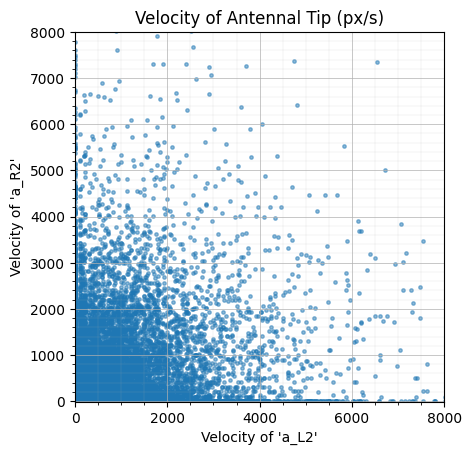

In [31]:
#Append the velocities as pairs to an array then plot the scatter array
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
# full_data_np = np.array(full_data)
velocity_mag = np.concat(full_data, axis=1)
Z = velocity_mag
Z2 = velocity_mag

fig, ax = plt.subplots()
plt.title("Velocity of Antennal Tip (px/s)")
ax.scatter(Z[0, :], Z[1, :], marker='o', s=6, alpha=0.5)
ax.set_xlabel("Velocity of 'a_L2'")
ax.set_ylabel("Velocity of 'a_R2'")
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-10, 8000)
ax.set_ylim(-10, 8000)
ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5)
ax.grid(visible=True, which='minor', linestyle='-', linewidth=0.1)
ax.minorticks_on()

# x1, x2, y1, y2 = (0, 50, 0, 50)  # subregion of the original image
# axins = ax.inset_axes(
#     [0.5, 0.5, 0.47, 0.47],
#     xlim=(x1, x2), ylim=(y1, y2))
# axins.grid(visible=True, which='major', linestyle='-', linewidth=0.5)
# axins.grid(visible=True, which='minor', linestyle='-', linewidth=0.1)
# axins.scatter(Z2.loc["a_L2"], Z2.loc["a_R2"], marker='o', s=6, alpha=0.5)
# axins.set_xlim(0, 50)
# axins.set_ylim(0, 50)
# axins.set_xticks([0, 10, 20, 30, 40, 50])



# ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2)
# plt.savefig("/Users/persie/Library/CloudStorage/OneDrive-UniversityofEdinburgh/PhD/Figures/Thesis Figures/Experiment Analysis/antenna_velocity_inset.svg")
plt.show()

In [59]:
#clean up non-paired points
clean_velocity = velocity_mag[:, np.all(~np.isnan(velocity_mag), axis=0)]
correlation = np.corrcoef(clean_velocity[0, :], clean_velocity[1, :])
correlation

array([[1.        , 0.04060462],
       [0.04060462, 1.        ]])

In [37]:
#Find the variance

array([1100.        , 1708.80074906, 2220.36033112, ...,    0.        ,
          0.        ,           nan], shape=(31865,))